# Walking Multi-Sensor Visualizer

Visualization-only notebook for folders with `right`, `left`, `trunk`, and `sacrum` synchronized CSV files. This notebook does not write to or change `extract_features.py`.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "imu_features").exists():
    REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from imu_features.config import PipelineConfig
from imu_features.utils import dominant_frequency, peak_step_summary, preprocess_activity_dataframe, select_motion_acc_signal
from imu_features.walk_features import _autocorrelation, _regularity_from_acf
from validation_plots import shared_validation as sv

CONFIG = PipelineConfig(dataset_root="Data_Sensors")
sv.configure(CONFIG, sv.plot_params_from_config(CONFIG))

def visible_sensor_items(sensor_data):
    return [(sensor, item) for sensor, item in sensor_data.items() if item is not None and SHOW_SENSOR.get(sensor, True)]

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
print(f"Setup complete | walk_threshold_k={CONFIG.window_gate.walk_threshold_k} | p2p_cap_scale={CONFIG.window_gate.p2p_cap_scale}")






Setup complete | walk_threshold_k=1.0 | p2p_cap_scale=0.3


In [2]:
LAST_SENSOR_DIR_PATH = REPO_ROOT / ".data_sensors_last_dir"
DEFAULT_SENSOR_ROOT = REPO_ROOT / "Data_Sensors" / "Converted Files_synchronized" / "NonStroke01" / "Visit1" / "Outside02"

# Default is False so rerunning the notebook does not create a Tkinter window.
# Set True only when you intentionally want to choose a new folder.
USE_TKINTER_FOLDER_DIALOG = True

# Optional: paste a folder path here to avoid Tkinter completely.
MANUAL_OUTSIDE_FOLDER = ""


def _last_sensor_dir(default_dir=DEFAULT_SENSOR_ROOT):
    try:
        if LAST_SENSOR_DIR_PATH.exists():
            cached = Path(LAST_SENSOR_DIR_PATH.read_text().strip()).expanduser()
            if cached.exists():
                return cached
    except OSError:
        pass
    return Path(default_dir)


def _remember_sensor_dir(selected_dir):
    try:
        LAST_SENSOR_DIR_PATH.write_text(str(Path(selected_dir).resolve()))
    except OSError:
        pass


def choose_outside_folder(initial_dir=None):
    import tkinter as tk
    from tkinter import filedialog

    start_dir = _last_sensor_dir(initial_dir or DEFAULT_SENSOR_ROOT)
    root = None
    selected = ""
    try:
        root = tk.Tk()
        root.title("Choose Outside Folder")
        root.resizable(False, False)
        root.attributes("-topmost", False)

        width, height = 260, 80
        root.update_idletasks()
        screen_w = root.winfo_screenwidth()
        screen_h = root.winfo_screenheight()
        x = max(0, int((screen_w - width) / 2))
        y = max(0, int((screen_h - height) / 2))
        root.geometry(f"{width}x{height}+{x}+{y}")

        tk.Label(root, text="Opening folder picker...", padx=20, pady=20).pack(expand=True, fill="both")
        root.lift()
        root.focus_force()
        root.update()

        selected = filedialog.askdirectory(
            parent=root,
            title="Choose an activity folder containing right/left/trunk/sacrum",
            initialdir=str(start_dir),
        )
    finally:
        if root is not None:
            try:
                root.withdraw()
                root.update_idletasks()
                root.update()
                root.quit()
                root.destroy()
            except tk.TclError:
                pass
            root = None

    if selected:
        selected = Path(selected).resolve()
        _remember_sensor_dir(selected)
        return selected
    return None


manual = str(MANUAL_OUTSIDE_FOLDER).strip()
if manual:
    OUTSIDE_FOLDER = Path(manual).expanduser().resolve()
    _remember_sensor_dir(OUTSIDE_FOLDER)
elif USE_TKINTER_FOLDER_DIALOG:
    OUTSIDE_FOLDER = choose_outside_folder()
else:
    OUTSIDE_FOLDER = _last_sensor_dir(DEFAULT_SENSOR_ROOT)

print("Selected folder:", OUTSIDE_FOLDER)
print("Tkinter opens only when USE_TKINTER_FOLDER_DIALOG=True.")


Selected folder: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS15/Visit1/OW03
Tkinter opens only when USE_TKINTER_FOLDER_DIALOG=True.


In [3]:

SENSOR_ORDER = ["right", "left", "trunk", "sacrum"]
SHOW_RIGHT = True
SHOW_LEFT = True
SHOW_TRUNK = True
SHOW_SACRUM = True
SHOW_SENSOR = {
    "right": SHOW_RIGHT,
    "left": SHOW_LEFT,
    "trunk": SHOW_TRUNK,
    "sacrum": SHOW_SACRUM,
}

VIS_STEP_SMOOTH_SIGMA = 2.0
VIS_STEP_MIN_DISTANCE_S = 0.37
VIS_STEP_PROMINENCE_SCALE = 1.0

def find_sensor_csv(outside_folder, sensor_name):
    outside_folder = Path(outside_folder)
    direct_dir = outside_folder / sensor_name
    if direct_dir.exists():
        csvs = sorted(direct_dir.glob("*synchronized*.csv")) or sorted(direct_dir.glob("*.csv"))
        if csvs:
            return csvs[0]
    matches = []
    for path in outside_folder.rglob("*.csv"):
        if sensor_name.lower() in [part.lower() for part in path.parts]:
            sync_rank = 0 if "synchronized" in path.name.lower() else 1
            matches.append((sync_rank, len(path.parts), path.name.lower(), path))
    if matches:
        return sorted(matches)[0][-1]
    return None


def refine_walk_summary_to_step_threshold_crossings(summary):
    refined = dict(summary)
    t_res = np.asarray(refined.get("t_res", []), dtype=float)
    smooth = np.asarray(refined.get("smoothed_signal", []), dtype=float)
    peak_indices = np.asarray(refined.get("peak_indices", []), dtype=int)
    threshold = float(refined.get("peak_threshold", refined.get("min_amp", np.nan)))
    if len(t_res) == 0 or len(smooth) != len(t_res) or len(peak_indices) == 0 or not np.isfinite(threshold):
        return refined

    first_peak_idx = int(peak_indices[0])
    last_peak_idx = int(peak_indices[-1])
    if first_peak_idx < 0 or last_peak_idx >= len(t_res):
        return refined

    below_before = np.where(
        np.isfinite(smooth[: first_peak_idx + 1])
        & (smooth[: first_peak_idx + 1] < threshold)
    )[0]
    if len(below_before):
        start_idx = min(int(below_before[-1]) + 1, first_peak_idx)
    else:
        above_before = np.where(
            np.isfinite(smooth[: first_peak_idx + 1])
            & (smooth[: first_peak_idx + 1] >= threshold)
        )[0]
        start_idx = int(above_before[0]) if len(above_before) else first_peak_idx

    below_after = np.where(
        np.isfinite(smooth[last_peak_idx:])
        & (smooth[last_peak_idx:] < threshold)
    )[0]
    if len(below_after):
        end_idx = int(last_peak_idx + below_after[0])
    else:
        end_idx = len(t_res) - 1

    start_t = float(t_res[start_idx])
    end_t = float(t_res[end_idx])
    if np.isfinite(start_t) and np.isfinite(end_t) and end_t > start_t:
        refined["p2p_start_time_s"] = refined.get("start_time_s", np.nan)
        refined["p2p_end_time_s"] = refined.get("end_time_s", np.nan)
        refined["start_time_s"] = start_t
        refined["end_time_s"] = end_t
        refined["duration_s"] = float(end_t - start_t)
        step_count = float(refined.get("step_count", np.nan))
        if np.isfinite(step_count) and refined["duration_s"] > 0:
            refined["cadence"] = float((step_count / refined["duration_s"]) * 60.0)
    return refined


def load_sensor_recording(outside_folder, sensor_name):
    csv_path = find_sensor_csv(outside_folder, sensor_name)
    if csv_path is None:
        return None
    raw = pd.read_csv(csv_path)
    df, meta = preprocess_activity_dataframe(raw, CONFIG)
    acc, acc_source = select_motion_acc_signal(df, CONFIG.prefer_useracc_for_motion)
    t = df["time_s"].to_numpy(dtype=float)
    summary = peak_step_summary(
        time_s=t,
        signal=acc,
        window_sec=CONFIG.window_gate.window_sec,
        threshold_k=CONFIG.window_gate.walk_threshold_k,
        fallback_min_amp=CONFIG.window_gate.walk_min_amp_threshold,
        min_duration_s=CONFIG.window_gate.walk_min_duration_s,
        smooth_sigma=VIS_STEP_SMOOTH_SIGMA,
        min_peak_distance_s=VIS_STEP_MIN_DISTANCE_S,
        peak_prominence_scale=VIS_STEP_PROMINENCE_SCALE,
        p2p_cap_scale=CONFIG.window_gate.p2p_cap_scale,
    )
    summary = refine_walk_summary_to_step_threshold_crossings(summary)
    return {
        "sensor": sensor_name,
        "path": csv_path,
        "df": df,
        "meta": meta,
        "time_s": t,
        "acc": np.asarray(acc, dtype=float),
        "acc_source": acc_source,
        "summary": summary,
    }


def load_all_sensors(outside_folder):
    loaded = {}
    for sensor in SENSOR_ORDER:
        loaded[sensor] = load_sensor_recording(outside_folder, sensor)
    return loaded

if OUTSIDE_FOLDER is None:
    SENSOR_DATA = {}
    print("No folder selected")
else:
    SENSOR_DATA = load_all_sensors(OUTSIDE_FOLDER)
    for sensor, item in SENSOR_DATA.items():
        if item is None:
            print(f"[missing] {sensor}")
        else:
            meta = item["meta"]
            print(f"[loaded] {sensor}: {item['path']} | n={len(item['df'])} | duration={meta.duration_s:.2f}s | source={item['acc_source']}")






[loaded] right: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS15/Visit1/OW03/right/MT_012005F9_000_00B42760_synchronized.csv | n=2495 | duration=24.99s | source=acc_mag_gravity_removed
[loaded] left: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS15/Visit1/OW03/left/MT_012005F9_000_00B426CC_synchronized.csv | n=1328 | duration=24.99s | source=acc_mag_gravity_removed
[loaded] trunk: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS15/Visit1/OW03/trunk/MT_012005F9_000_00B4276D_synchronized.csv | n=2342 | duration=24.98s | source=acc_mag_gravity_removed
[loaded] sacrum: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS15/Visit1/OW03/sacrum/MT_012005F9_000_00B42660_synchronized.csv | n=1638 | duration=24.99s | source=acc_mag_gravity_removed


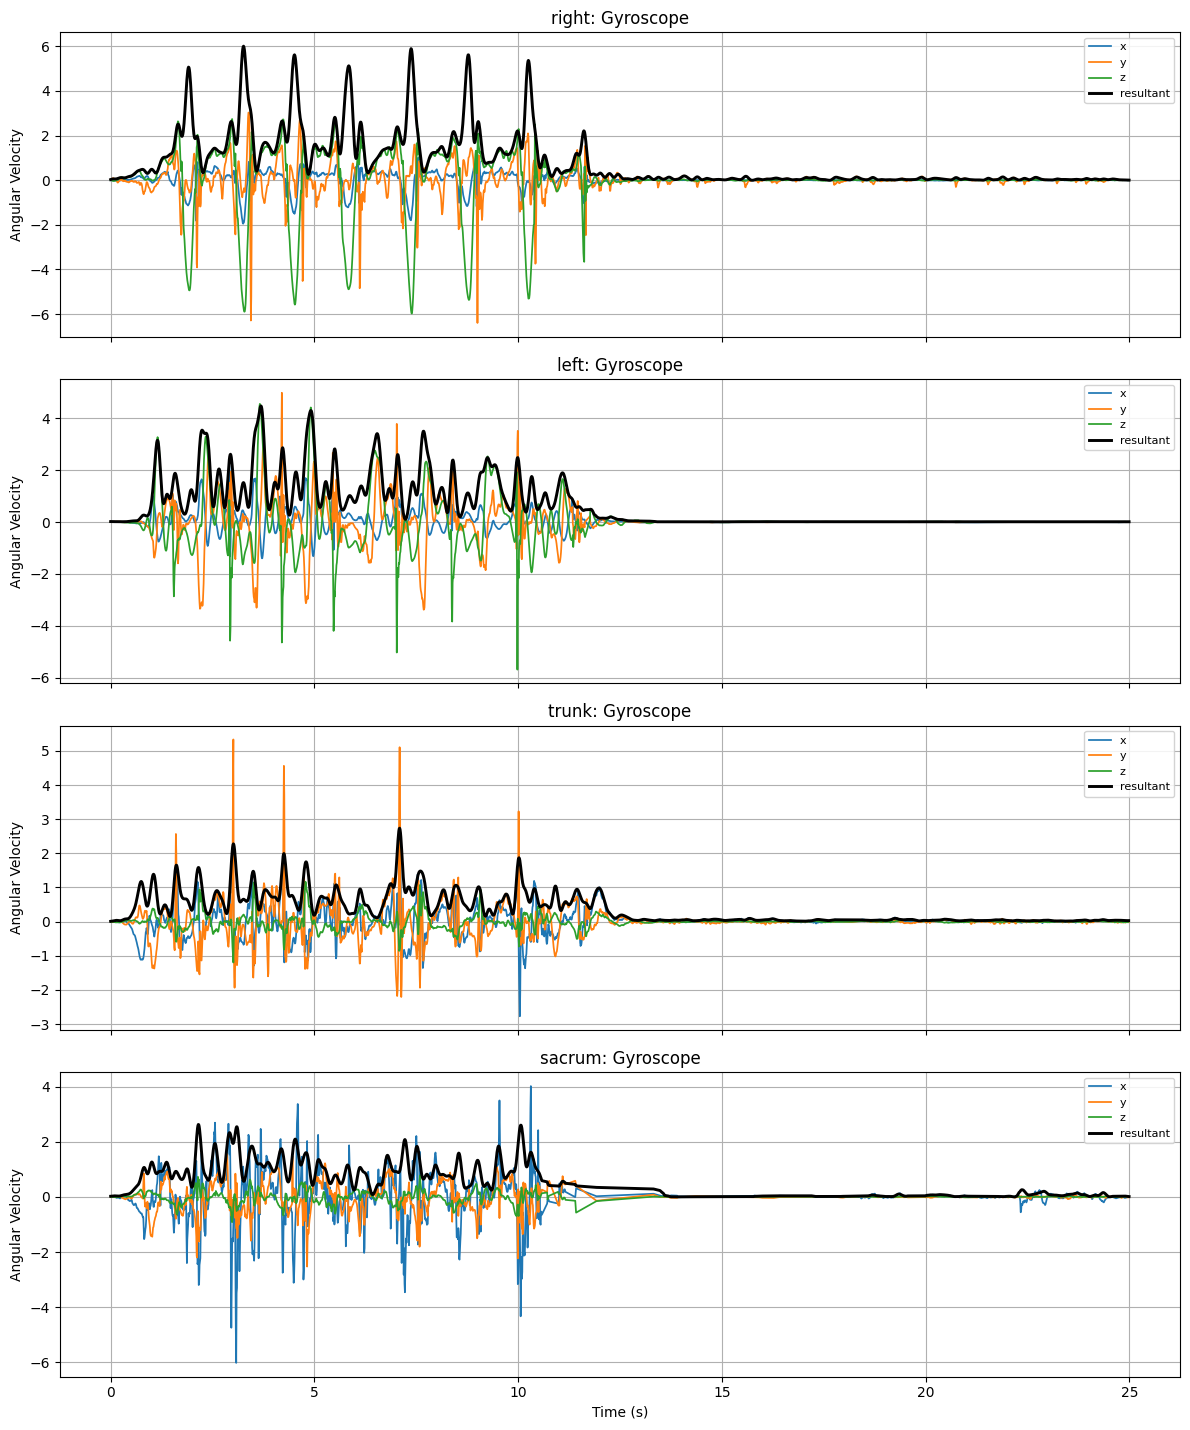

In [4]:
SHOW_GYRO_X = True
SHOW_GYRO_Y = True
SHOW_GYRO_Z = True
SHOW_GYRO_RESULTANT = True


def plot_sensor_gyroscope(sensor_data):
    items = visible_sensor_items(sensor_data)
    if not items:
        print("No visible sensors. Set one of SHOW_RIGHT/SHOW_LEFT/SHOW_TRUNK/SHOW_SACRUM to True and rerun.")
        return

    gyro_components = [
        ("gyro_x", SHOW_GYRO_X, "x"),
        ("gyro_y", SHOW_GYRO_Y, "y"),
        ("gyro_z", SHOW_GYRO_Z, "z"),
        ("gyro_mag", SHOW_GYRO_RESULTANT, "resultant"),
    ]
    active_components = [(col, label) for col, show, label in gyro_components if show]
    if not active_components:
        print("No gyroscope components selected")
        return

    fig, axes = plt.subplots(len(items), 1, figsize=(12, 3.6 * len(items)), sharex=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (sensor, item) in zip(axes, items):
        df = item["df"]
        t = item["time_s"]
        for col, label in active_components:
            if col in df:
                linewidth = 2.1 if label == "resultant" else 1.25
                color = "black" if label == "resultant" else None
                ax.plot(t, df[col].to_numpy(dtype=float), linewidth=linewidth, color=color, label=label)
        ax.set_title(f"{sensor}: Gyroscope")
        ax.set_ylabel("Angular Velocity")
        ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_sensor_gyroscope(SENSOR_DATA)


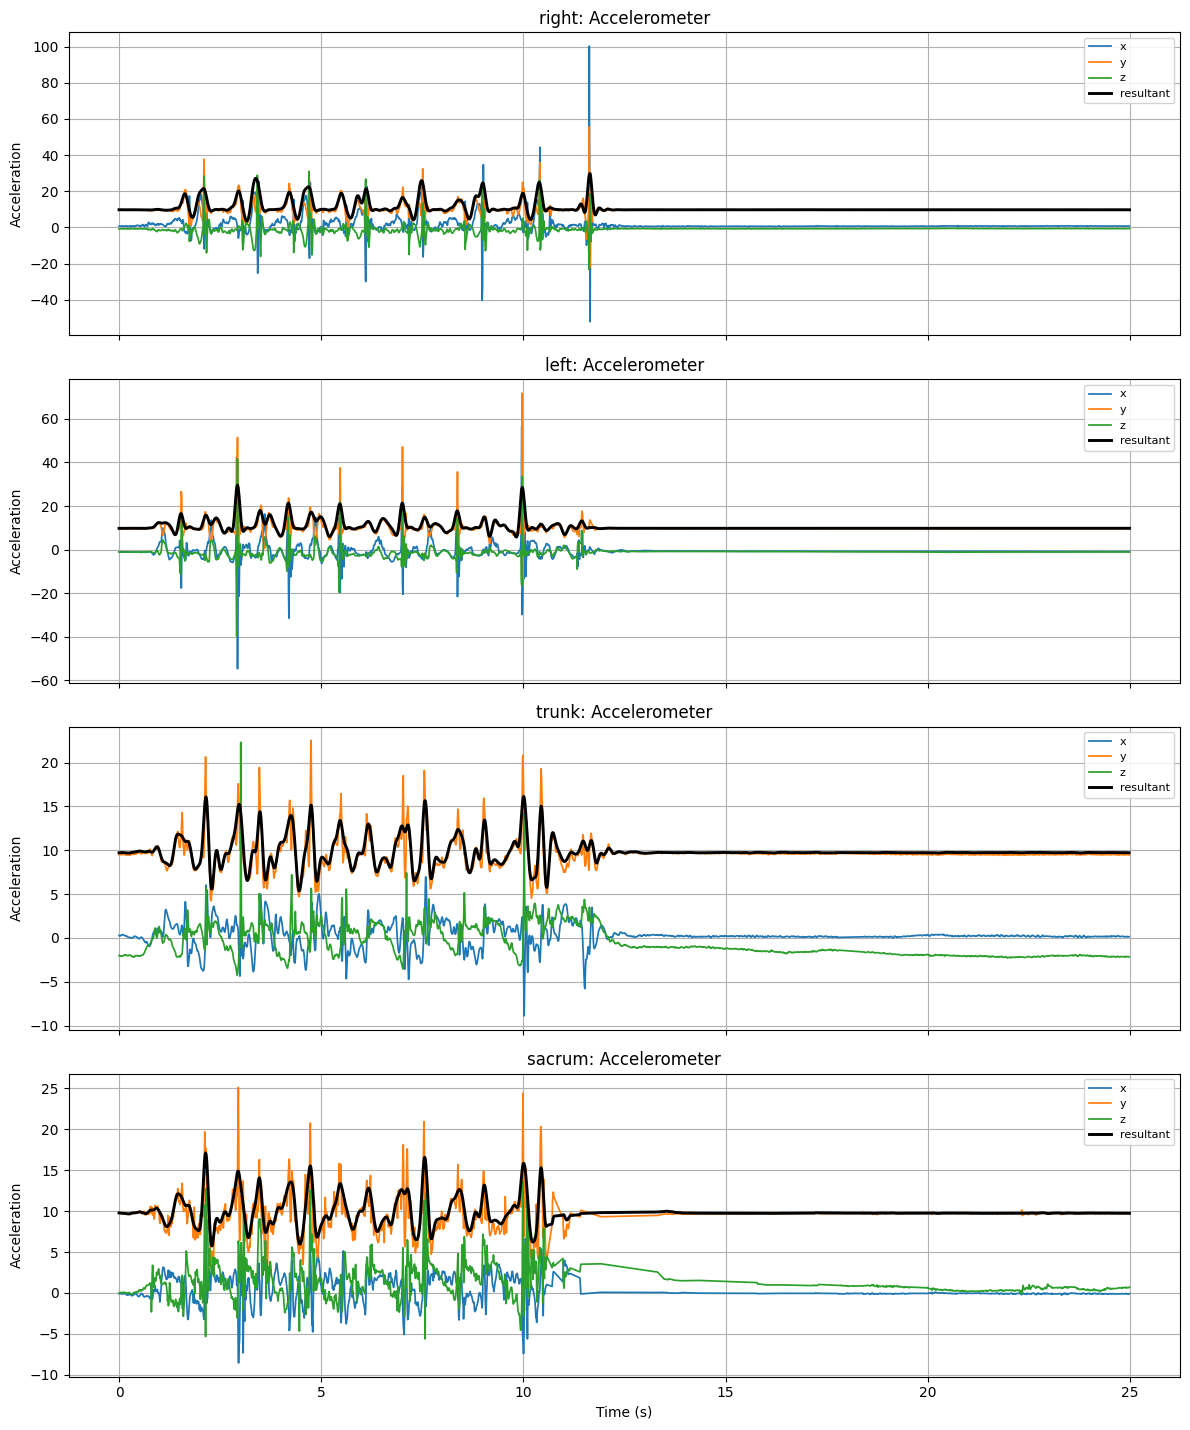

In [5]:
SHOW_ACCEL_X = True
SHOW_ACCEL_Y = True
SHOW_ACCEL_Z = True
SHOW_ACCEL_RESULTANT = True


def plot_sensor_accelerometer(sensor_data):
    items = visible_sensor_items(sensor_data)
    if not items:
        print("No visible sensors. Set one of SHOW_RIGHT/SHOW_LEFT/SHOW_TRUNK/SHOW_SACRUM to True and rerun.")
        return

    accel_components = [
        ("accel_x", SHOW_ACCEL_X, "x"),
        ("accel_y", SHOW_ACCEL_Y, "y"),
        ("accel_z", SHOW_ACCEL_Z, "z"),
        ("acc_mag", SHOW_ACCEL_RESULTANT, "resultant"),
    ]
    active_components = [(col, label) for col, show, label in accel_components if show]
    if not active_components:
        print("No accelerometer components selected")
        return

    fig, axes = plt.subplots(len(items), 1, figsize=(12, 3.6 * len(items)), sharex=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (sensor, item) in zip(axes, items):
        df = item["df"]
        t = item["time_s"]
        for col, label in active_components:
            if col in df:
                linewidth = 2.1 if label == "resultant" else 1.25
                color = "black" if label == "resultant" else None
                ax.plot(t, df[col].to_numpy(dtype=float), linewidth=linewidth, color=color, label=label)
        ax.set_title(f"{sensor}: Accelerometer")
        ax.set_ylabel("Acceleration")
        ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_sensor_accelerometer(SENSOR_DATA)


In [6]:
def walking_sensor_extra_features(item):
    s = item["summary"]
    acc = np.asarray(item["acc"], dtype=float)
    fs_hz = float(item["meta"].fs_hz)
    active_mask = np.asarray(s.get("active_mask", []), dtype=bool)

    peak_times = np.asarray(s.get("peak_times", []), dtype=float)
    peak_times = peak_times[np.isfinite(peak_times)]
    if len(peak_times) >= 2:
        step_times = np.diff(peak_times)
    else:
        active_cad = np.asarray(s.get("cad", []), dtype=float)
        active_cad = active_cad[np.isfinite(active_cad) & (active_cad > 0)]
        step_times = 1.0 / active_cad if len(active_cad) else np.array([], dtype=float)

    mean_step_time = np.nan
    step_time_std = np.nan
    step_time_cv = np.nan
    if len(step_times):
        mean_step_time = float(np.nanmean(step_times))
        step_time_std = float(np.nanstd(step_times))
        step_time_cv = step_time_std / mean_step_time if mean_step_time > 0 else np.nan

    if len(active_mask) == len(acc) and np.any(active_mask):
        acc_stats = acc[active_mask]
    else:
        acc_stats = acc

    dom_freq = dominant_frequency(acc_stats, fs_hz)
    acf = _autocorrelation(acc_stats)
    lag_samples = np.nan
    if np.isfinite(mean_step_time) and mean_step_time > 0 and np.isfinite(fs_hz):
        lag_samples = int(round(mean_step_time * fs_hz))
    elif np.isfinite(dom_freq) and dom_freq > 0 and np.isfinite(fs_hz):
        lag_samples = int(round(fs_hz / dom_freq))

    step_regularity = np.nan
    stride_regularity = np.nan
    if np.isfinite(lag_samples):
        lag_samples = int(lag_samples)
        step_regularity = _regularity_from_acf(acf, lag_samples)
        stride_regularity = _regularity_from_acf(acf, 2 * lag_samples)

    return {
        "mean_step_time": mean_step_time,
        "step_time_std": step_time_std,
        "step_time_cv": step_time_cv,
        "dominant_frequency": dom_freq,
        "step_regularity": step_regularity,
        "stride_regularity": stride_regularity,
    }


def sensor_summary_row(sensor, item):
    s = item["summary"]
    extra = walking_sensor_extra_features(item)
    return {
        "sensor": sensor,
        "file": item["path"].name,
        "acc_source": item["acc_source"],
        "fs_hz": item["meta"].fs_hz,
        "start_time_s": s.get("start_time_s", np.nan),
        "end_time_s": s.get("end_time_s", np.nan),
        "duration_s": s.get("duration_s", np.nan),
        "step_count": s.get("step_count", np.nan),
        "cadence": s.get("cadence", np.nan),
        "walk_threshold_k": CONFIG.window_gate.walk_threshold_k,
        "p2p_cap_scale": np.nan if CONFIG.window_gate.p2p_cap_scale is None else CONFIG.window_gate.p2p_cap_scale,
        "p2p_threshold": s.get("min_amp", np.nan),
        **extra,
    }

summary_table = pd.DataFrame(
    [sensor_summary_row(sensor, item) for sensor, item in SENSOR_DATA.items() if item is not None]
)
if len(summary_table):
    display(summary_table.round(3))
else:
    print("No sensor data loaded")





,sensor,file,acc_source,fs_hz,start_time_s,end_time_s,duration_s,step_count,cadence,walk_threshold_k,p2p_cap_scale,p2p_threshold,mean_step_time,step_time_std,step_time_cv,dominant_frequency,step_regularity,stride_regularity
0,right,MT_012005F9_000_00B42760_synchronized.csv,acc_mag_gravity_removed,100.0,1.50,11.74,10.24,15.0,87.891,1.0,0.3,0.702,0.715,0.254,0.356,1.415,-0.072,0.197
1,left,MT_012005F9_000_00B426CC_synchronized.csv,acc_mag_gravity_removed,100.0,1.49,10.07,8.58,13.0,90.909,1.0,0.3,2.808,0.703,0.165,0.235,1.753,0.142,0.055
2,trunk,MT_012005F9_000_00B4276D_synchronized.csv,acc_mag_gravity_removed,100.0,1.41,10.50,9.09,14.0,92.409,1.0,0.3,1.430,0.690,0.176,0.255,1.453,0.174,0.290
3,sacrum,MT_012005F9_000_00B42660_synchronized.csv,acc_mag_gravity_removed,100.0,1.38,10.51,9.13,14.0,92.004,1.0,0.3,0.899,0.690,0.179,0.259,1.448,0.136,0.315


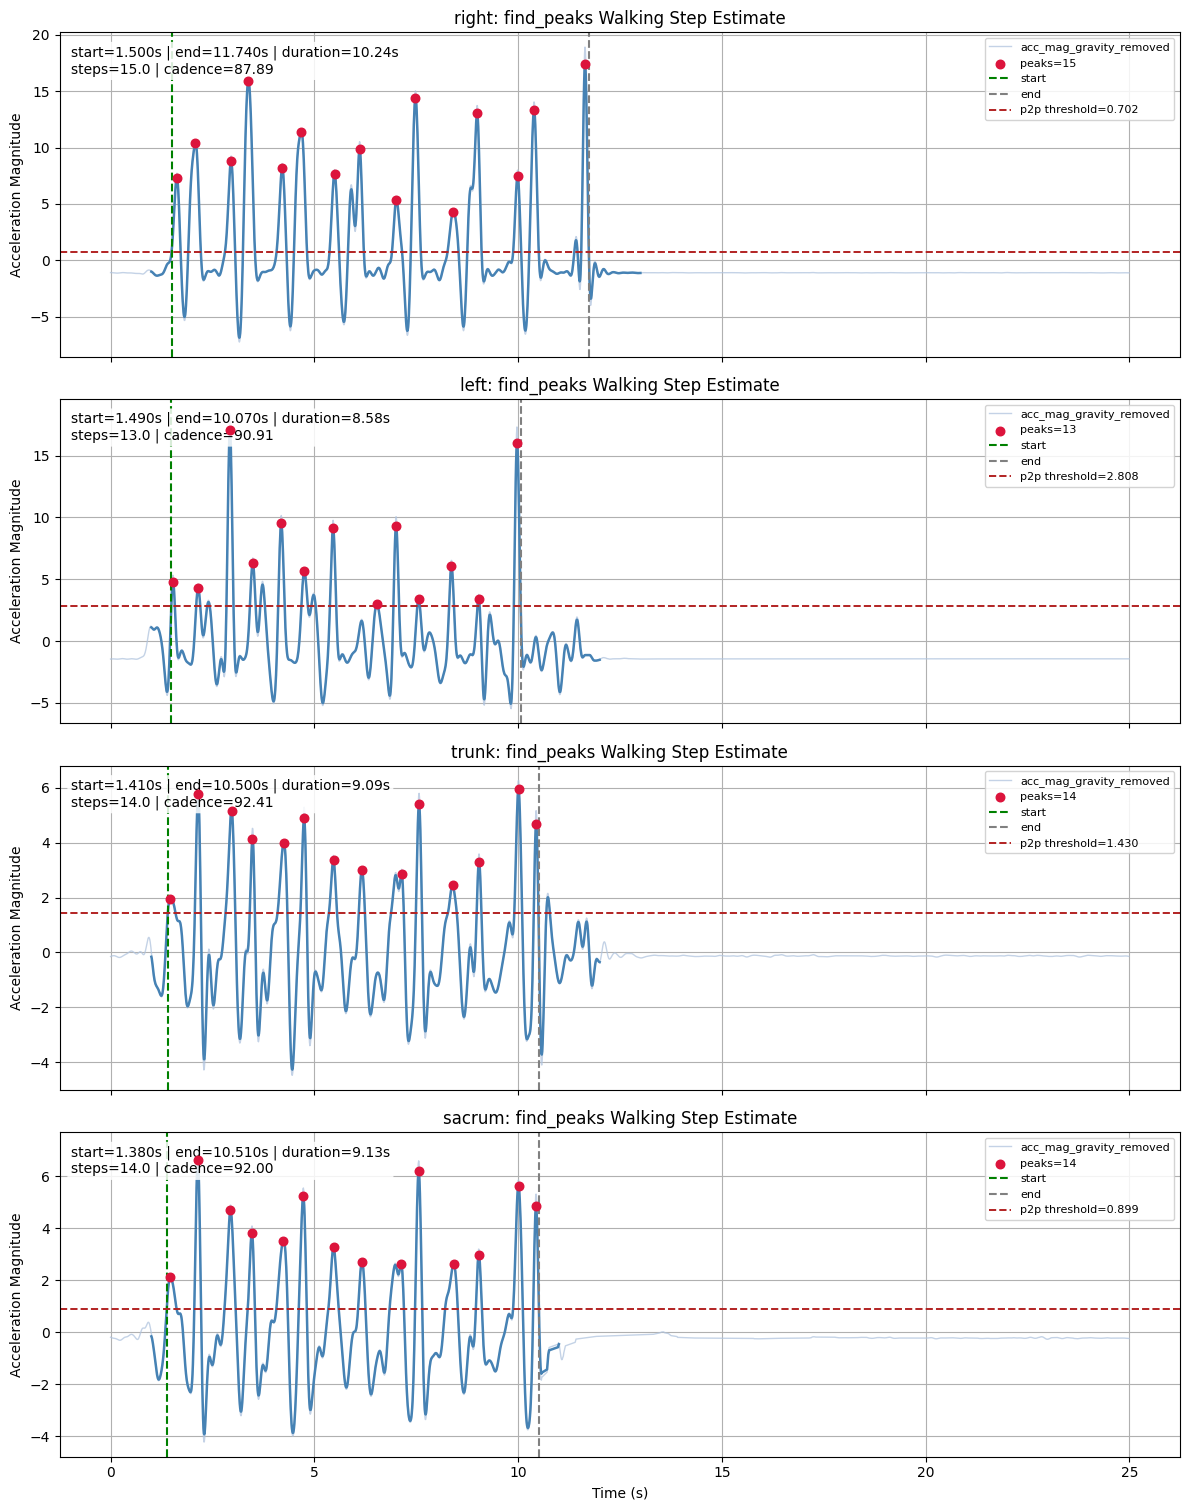

In [7]:
def plot_walking_sensor_steps(sensor_data):
    items = visible_sensor_items(sensor_data)
    if not items:
        print("No visible sensors. Set one of SHOW_RIGHT/SHOW_LEFT/SHOW_TRUNK/SHOW_SACRUM to True and rerun.")
        return

    fig, axes = plt.subplots(len(items), 1, figsize=(12, 3.8 * len(items)), sharex=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (sensor, item) in zip(axes, items):
        t = item["time_s"]
        acc = item["acc"]
        summary = item["summary"]
        start_t = float(summary.get("start_time_s", np.nan))
        end_t = float(summary.get("end_time_s", np.nan))
        duration = float(summary.get("duration_s", np.nan))
        step_count = float(summary.get("step_count", np.nan))
        cadence = float(summary.get("cadence", np.nan))
        min_amp = float(summary.get("min_amp", np.nan))
        peak_times = np.asarray(summary.get("peak_times", []), dtype=float)
        peak_values = np.asarray(summary.get("peak_values", []), dtype=float)
        smooth = np.asarray(summary.get("smoothed_signal", []), dtype=float)
        t_smooth = np.asarray(summary.get("t_res", []), dtype=float)

        ax.plot(t, acc, color="lightsteelblue", linewidth=1.0, alpha=0.75, label=item["acc_source"])
        if len(smooth) == len(t_smooth):
            ax.plot(t_smooth, smooth, color="steelblue", linewidth=1.8)
        if len(peak_times) == len(peak_values) and len(peak_times):
            ax.scatter(peak_times, peak_values, color="crimson", s=38, zorder=5, label=f"peaks={len(peak_times)}")
        if np.isfinite(start_t):
            ax.axvline(start_t, color="green", linestyle="--", linewidth=1.5, label="start")
        if np.isfinite(end_t):
            ax.axvline(end_t, color="gray", linestyle="--", linewidth=1.5, label="end")
        if np.isfinite(min_amp):
            ax.axhline(min_amp, color="firebrick", linestyle="--", linewidth=1.4, label=f"p2p threshold={min_amp:.3f}")

        ax.set_title(f"{sensor}: Walking Step Estimate")
        ax.set_ylabel("Acceleration Magnitude")
        ax.text(
            0.01,
            0.96,
            f"start={start_t:.3f}s | end={end_t:.3f}s | duration={duration:.2f}s\nsteps={step_count:.1f} | cadence={cadence:.2f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.25"),
        )
        ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_walking_sensor_steps(SENSOR_DATA)


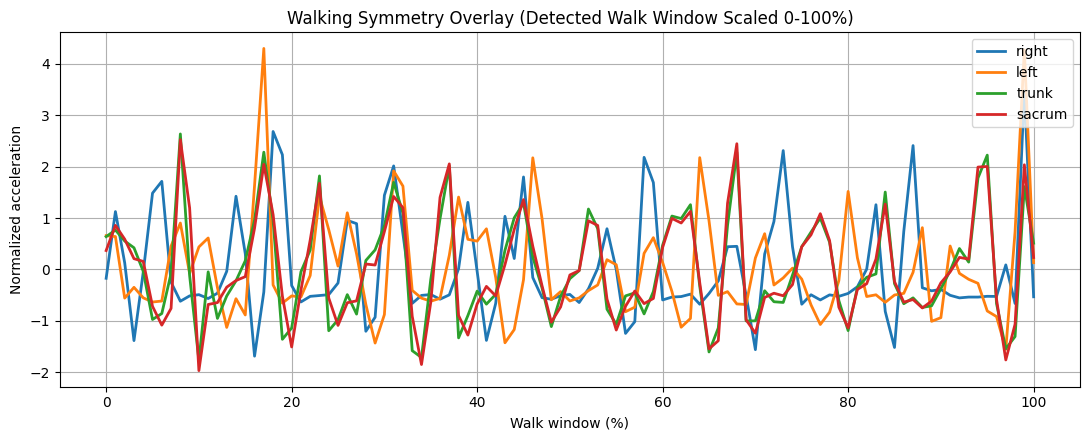

,sensor_a,sensor_b,xcorr_peak_correlation
0,right,left,0.243
1,right,trunk,0.262
2,right,sacrum,0.297
3,left,trunk,0.312
4,left,sacrum,0.306
5,trunk,sacrum,0.961


In [8]:
def windowed_signal_for_summary(item):
    t = item["time_s"]
    acc = item["acc"]
    summary = item["summary"]
    start_t = float(summary.get("start_time_s", np.nan))
    end_t = float(summary.get("end_time_s", np.nan))
    if not np.isfinite(start_t) or not np.isfinite(end_t) or end_t <= start_t:
        mask = np.isfinite(t) & np.isfinite(acc)
    else:
        mask = (t >= start_t) & (t <= end_t) & np.isfinite(t) & np.isfinite(acc)
    return t[mask], acc[mask]


def resample_to_percent_cycle(t, signal, n=101):
    t = np.asarray(t, dtype=float)
    signal = np.asarray(signal, dtype=float)
    keep = np.isfinite(t) & np.isfinite(signal)
    t = t[keep]
    signal = signal[keep]
    if len(t) < 3 or t[-1] <= t[0]:
        return np.linspace(0, 100, n), np.full(n, np.nan)
    pct = (t - t[0]) / (t[-1] - t[0]) * 100.0
    pct_grid = np.linspace(0, 100, n)
    y = np.interp(pct_grid, pct, signal)
    std = np.nanstd(y)
    if np.isfinite(std) and std > 0:
        y = (y - np.nanmean(y)) / std
    else:
        y = y - np.nanmean(y)
    return pct_grid, y


def peak_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    keep = np.isfinite(a) & np.isfinite(b)
    a = a[keep]
    b = b[keep]
    if len(a) < 3 or np.allclose(a, a[0]) or np.allclose(b, b[0]):
        return np.nan
    a = a - np.mean(a)
    b = b - np.mean(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom <= 0:
        return np.nan
    corr = np.correlate(a, b, mode="full") / denom
    return float(np.nanmax(corr))

cycle_curves = {}
for sensor, item in SENSOR_DATA.items():
    if item is None:
        continue
    t_win, acc_win = windowed_signal_for_summary(item)
    pct, y = resample_to_percent_cycle(t_win, acc_win)
    cycle_curves[sensor] = y

visible = [sensor for sensor in SENSOR_ORDER if SHOW_SENSOR.get(sensor, True) and sensor in cycle_curves]
if visible:
    plt.figure(figsize=(11, 4.5))
    pct = np.linspace(0, 100, 101)
    for sensor in visible:
        plt.plot(pct, cycle_curves[sensor], linewidth=2.0, label=sensor)
    plt.title("Walking Symmetry Overlay (Detected Walk Window Scaled 0-100%)")
    plt.xlabel("Walk window (%)")
    plt.ylabel("Normalized acceleration")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print("No visible cycle curves")

corr_rows = []
for i, a in enumerate(SENSOR_ORDER):
    for b in SENSOR_ORDER[i + 1:]:
        if a in cycle_curves and b in cycle_curves:
            corr_rows.append({"sensor_a": a, "sensor_b": b, "xcorr_peak_correlation": peak_corr(cycle_curves[a], cycle_curves[b])})

if corr_rows:
    display(pd.DataFrame(corr_rows).round(3))
